# AIS SFP Distance Prediction Training

Train an image-based position predictor from the Hugging Face `vision_offset_dataset`.
Data is expected under `ws_aic/data/distance_prediction/SFP`, and checkpoints are saved under `ws_aic/model`.

lr 1e-4 -> 3e-4 </br>
EARLY_STOPPINGP_ATIENCE 10 -> 15 </br>
scheduler 0.5 -> 0,75

In [18]:
from pathlib import Path
import sys

PROJECT_DIR = Path('/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/ais/ais_distance_prediction')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

PROJECT_DIR

PosixPath('/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/ais/ais_distance_prediction')

In [19]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from model import (
    VisionOffsetDataset,
    build_resnet_position_model,
    compute_target_stats,
    download_vision_offset_dataset,
    evaluate,
    fit,
    load_samples,
    seed_everything,
    split_samples_by_episode,
)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [20]:
DATASET_ROOT = Path('/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/distance_prediction/SFP')
WEIGHT_ROOT = Path('/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/model')

CAMERAS = ('left', 'center', 'right')
TARGET_KEYS = ('x_mm', 'y_mm', 'z_mm')
IMAGE_SIZE = (256, 288)
BATCH_SIZE = 32
NUM_WORKERS = 8
EPOCHS = 100
LR = 3e-4
WEIGHT_DECAY = 1e-4
BACKBONE = 'resnet50'
PRETRAINED = True
AGGREGATION = 'concat'
NUM_PORT_HEADS = 2
EXPAND_ALL_PORTS = False
VAL_EVERY_N = 5
MAX_TRAIN_BATCHES = None  # Set to None for full training.
MAX_VAL_BATCHES = None  # Set to None for full validation.
EARLY_STOPPING_PATIENCE = 15
EARLY_STOPPING_MIN_DELTA = 0.05
EARLY_STOPPING_MONITOR = 'euclidean'
RUN_NAME = f"sfp_distance_{BACKBONE}_{'_'.join(CAMERAS)}_{AGGREGATION}_2"

DATASET_ROOT, WEIGHT_ROOT / RUN_NAME

(PosixPath('/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/distance_prediction/SFP'),
 PosixPath('/home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/model/sfp_distance_resnet50_left_center_right_concat_2'))

In [21]:
from collections import Counter

def split_samples_by_grid_holdout(samples, *, every_n=5):
    train, val = [], []
    for sample in samples:
        row = dict(sample)
        step_index = int(row.get('step_index', 0))
        if step_index % every_n == 0:
            val.append(row)
        else:
            train.append(row)
    return train, val, []


if not (DATASET_ROOT / 'samples.jsonl').is_file():
    raise FileNotFoundError(f'Missing SFP samples.jsonl: {DATASET_ROOT / "samples.jsonl"}')

samples = load_samples(DATASET_ROOT)
missing_images = [
    DATASET_ROOT / sample['images'][camera]
    for sample in samples
    for camera in CAMERAS
    if not (DATASET_ROOT / sample['images'][camera]).is_file()
]
if missing_images:
    preview = '\n'.join(str(path) for path in missing_images[:5])
    raise FileNotFoundError(f'{len(missing_images)} image files are missing. First missing files:\n{preview}')

train_samples, val_samples, test_samples = split_samples_by_grid_holdout(
    samples,
    every_n=VAL_EVERY_N,
)
target_stats = compute_target_stats(
    train_samples,
    TARGET_KEYS,
    expand_all_ports=EXPAND_ALL_PORTS,
)

print(f'dataset_root: {DATASET_ROOT}')
print(f'raw samples: total={len(samples)} train={len(train_samples)} val={len(val_samples)} test={len(test_samples)}')
print(f'effective rows: train={len(train_samples) * (NUM_PORT_HEADS if EXPAND_ALL_PORTS else 1)} '
      f'val={len(val_samples) * (NUM_PORT_HEADS if EXPAND_ALL_PORTS else 1)}')
print(f'images checked: {len(samples) * len(CAMERAS)}')
print('ports:', dict(Counter(sample.get('port_name', 'unknown') for sample in samples)))
print('label frame example:', samples[0]['label']['frame'])
print('target mean:', target_stats['mean'].tolist())
print('target std :', target_stats['std'].tolist())

dataset_root: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/data/distance_prediction/SFP
raw samples: total=10000 train=8000 val=2000 test=0
effective rows: train=8000 val=2000
images checked: 30000
ports: {'sfp_port_0': 5000, 'sfp_port_1': 5000}
label frame example: task_board/nic_card_mount_0/sfp_port_0_link_entrance
target mean: [-0.19905997812747955, -0.3419622480869293, -20.417387008666992]
target std : [6.551285743713379, 7.665936470031738, 11.511677742004395]


In [22]:
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [23]:
train_dataset = VisionOffsetDataset(
    DATASET_ROOT,
    samples=train_samples,
    cameras=CAMERAS,
    target_keys=TARGET_KEYS,
    transform=train_transform,
    target_mean=target_stats['mean'],
    target_std=target_stats['std'],
    expand_all_ports=EXPAND_ALL_PORTS,
)
val_dataset = VisionOffsetDataset(
    DATASET_ROOT,
    samples=val_samples,
    cameras=CAMERAS,
    target_keys=TARGET_KEYS,
    transform=eval_transform,
    target_mean=target_stats['mean'],
    target_std=target_stats['std'],
    expand_all_ports=EXPAND_ALL_PORTS,
)

pin_memory = device.type == 'cuda'
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
    persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
    persistent_workers=NUM_WORKERS > 0,
)

batch = next(iter(train_loader))
batch['image'].shape, batch['target'].shape, batch['port_id'][:8], batch['raw_target'][:3]

(torch.Size([32, 3, 3, 256, 288]),
 torch.Size([32, 3]),
 tensor([1, 0, 1, 0, 1, 1, 0, 0]),
 tensor([[ -4.7487,   0.5859, -38.2989],
         [  4.3804, -11.0259, -14.8430],
         [ -1.3019,   1.5642, -32.5315]]))

In [24]:
model = build_resnet_position_model(
    backbone_name=BACKBONE,
    pretrained=PRETRAINED,
    output_dim=len(TARGET_KEYS),
    hidden_dim=256,
    dropout=0.2,
    aggregation=AGGREGATION,
    num_views=len(CAMERAS),
    num_port_heads=NUM_PORT_HEADS,
)
model.to(device)

optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.75,
    patience=3,
)

sum(p.numel() for p in model.parameters() if p.requires_grad)


26720838

In [8]:
config = {
    'dataset_root': str(DATASET_ROOT),
    'cameras': CAMERAS,
    'target_keys': TARGET_KEYS,
    'target_mean': target_stats['mean'].tolist(),
    'target_std': target_stats['std'].tolist(),
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'backbone': BACKBONE,
    'pretrained': PRETRAINED,
    'aggregation': AGGREGATION,
    'num_views': len(CAMERAS),
    'num_port_heads': NUM_PORT_HEADS,
    'expand_all_ports': EXPAND_ALL_PORTS,
    'max_train_batches': MAX_TRAIN_BATCHES,
    'max_val_batches': MAX_VAL_BATCHES,
    'early_stopping': {
        'monitor': EARLY_STOPPING_MONITOR,
        'mode': 'min',
        'patience': EARLY_STOPPING_PATIENCE,
        'min_delta': EARLY_STOPPING_MIN_DELTA,
    },
    'label_frame_mode': samples[0]['label'].get('frame_mode'),
    'label_coordinate': samples[0]['label'].get('coordinate'),
    'split': {'name': 'grid_holdout', 'val_every_n': VAL_EVERY_N},
}

history = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=EPOCHS,
    weight_dir=WEIGHT_ROOT,
    run_name=RUN_NAME,
    scheduler=scheduler,
    target_mean=target_stats['mean'],
    target_std=target_stats['std'],
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    early_stopping_monitor=EARLY_STOPPING_MONITOR,
    max_train_batches=MAX_TRAIN_BATCHES,
    max_val_batches=MAX_VAL_BATCHES,
    config=config,
)
print(f'best checkpoint: {WEIGHT_ROOT / RUN_NAME / "best.pt"}')
history[-1]

epochs:   0%|          | 0/100 [00:00<?, ?it/s]

train 1/100:   0%|          | 0/250 [00:03<?, ?it/s]

val 1/100:   0%|          | 0/63 [00:00<?, ?it/s]

epoch=001 lr=3.00e-04 train_loss=0.0647 val_loss=0.0093 val_mae=0.932 val_euclidean=1.864


train 2/100:   0%|          | 0/250 [00:00<?, ?it/s]

...

epoch=064 lr=1.69e-05 train_loss=0.0094 val_loss=0.0004 val_mae=0.198 val_euclidean=0.407


train 65/100:   0%|          | 0/250 [00:00<?, ?it/s]

val 65/100:   0%|          | 0/63 [00:00<?, ?it/s]

epoch=065 lr=1.69e-05 train_loss=0.0094 val_loss=0.0007 val_mae=0.255 val_euclidean=0.519
early stopping at epoch=065; best_epoch=050 best_euclidean=0.4050
best checkpoint: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/model/sfp_distance_resnet50_left_center_right_concat_2/best.pt


{'epoch': 65.0,
 'lr': 1.6894054412841797e-05,
 'lr_before_scheduler': 1.6894054412841797e-05,
 'scheduler_metric': 0.5193023681640625,
 'train_loss': 0.009407589673995971,
 'val_loss': 0.0006791578168049455,
 'val_mae': 0.2551712095737457,
 'val_rmse': 0.33656638860702515,
 'val_euclidean': 0.5193023681640625}

In [25]:
val_metrics = evaluate(
    model,
    val_loader,
    device,
    target_mean=target_stats['mean'],
    target_std=target_stats['std'],
)
val_metrics

val:   0%|          | 0/63 [00:00<?, ?it/s]

{'loss': 0.4661888964176178,
 'mae': 7.484555244445801,
 'rmse': 8.904502868652344,
 'euclidean': 14.658543586730957}

In [ ]:
model.eval()
batch = next(iter(val_loader))
with torch.inference_mode():
    pred = model(batch['image'].to(device), batch['port_id'].to(device)).cpu()
pred_mm = pred * target_stats['std'] + target_stats['mean']
preview = torch.cat([pred_mm[:8], batch['raw_target'][:8]], dim=1)
print('columns: pred_x pred_y pred_z target_x target_y target_z')
preview

loaded best checkpoint: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/model/sfp_distance_resnet50_left_center_right_concat_2/best.pt
checkpoint metrics: {'loss': 0.0004771019103936851, 'mae': 0.2026224583387375, 'rmse': 0.2653844654560089, 'euclidean': 0.4050227999687195}


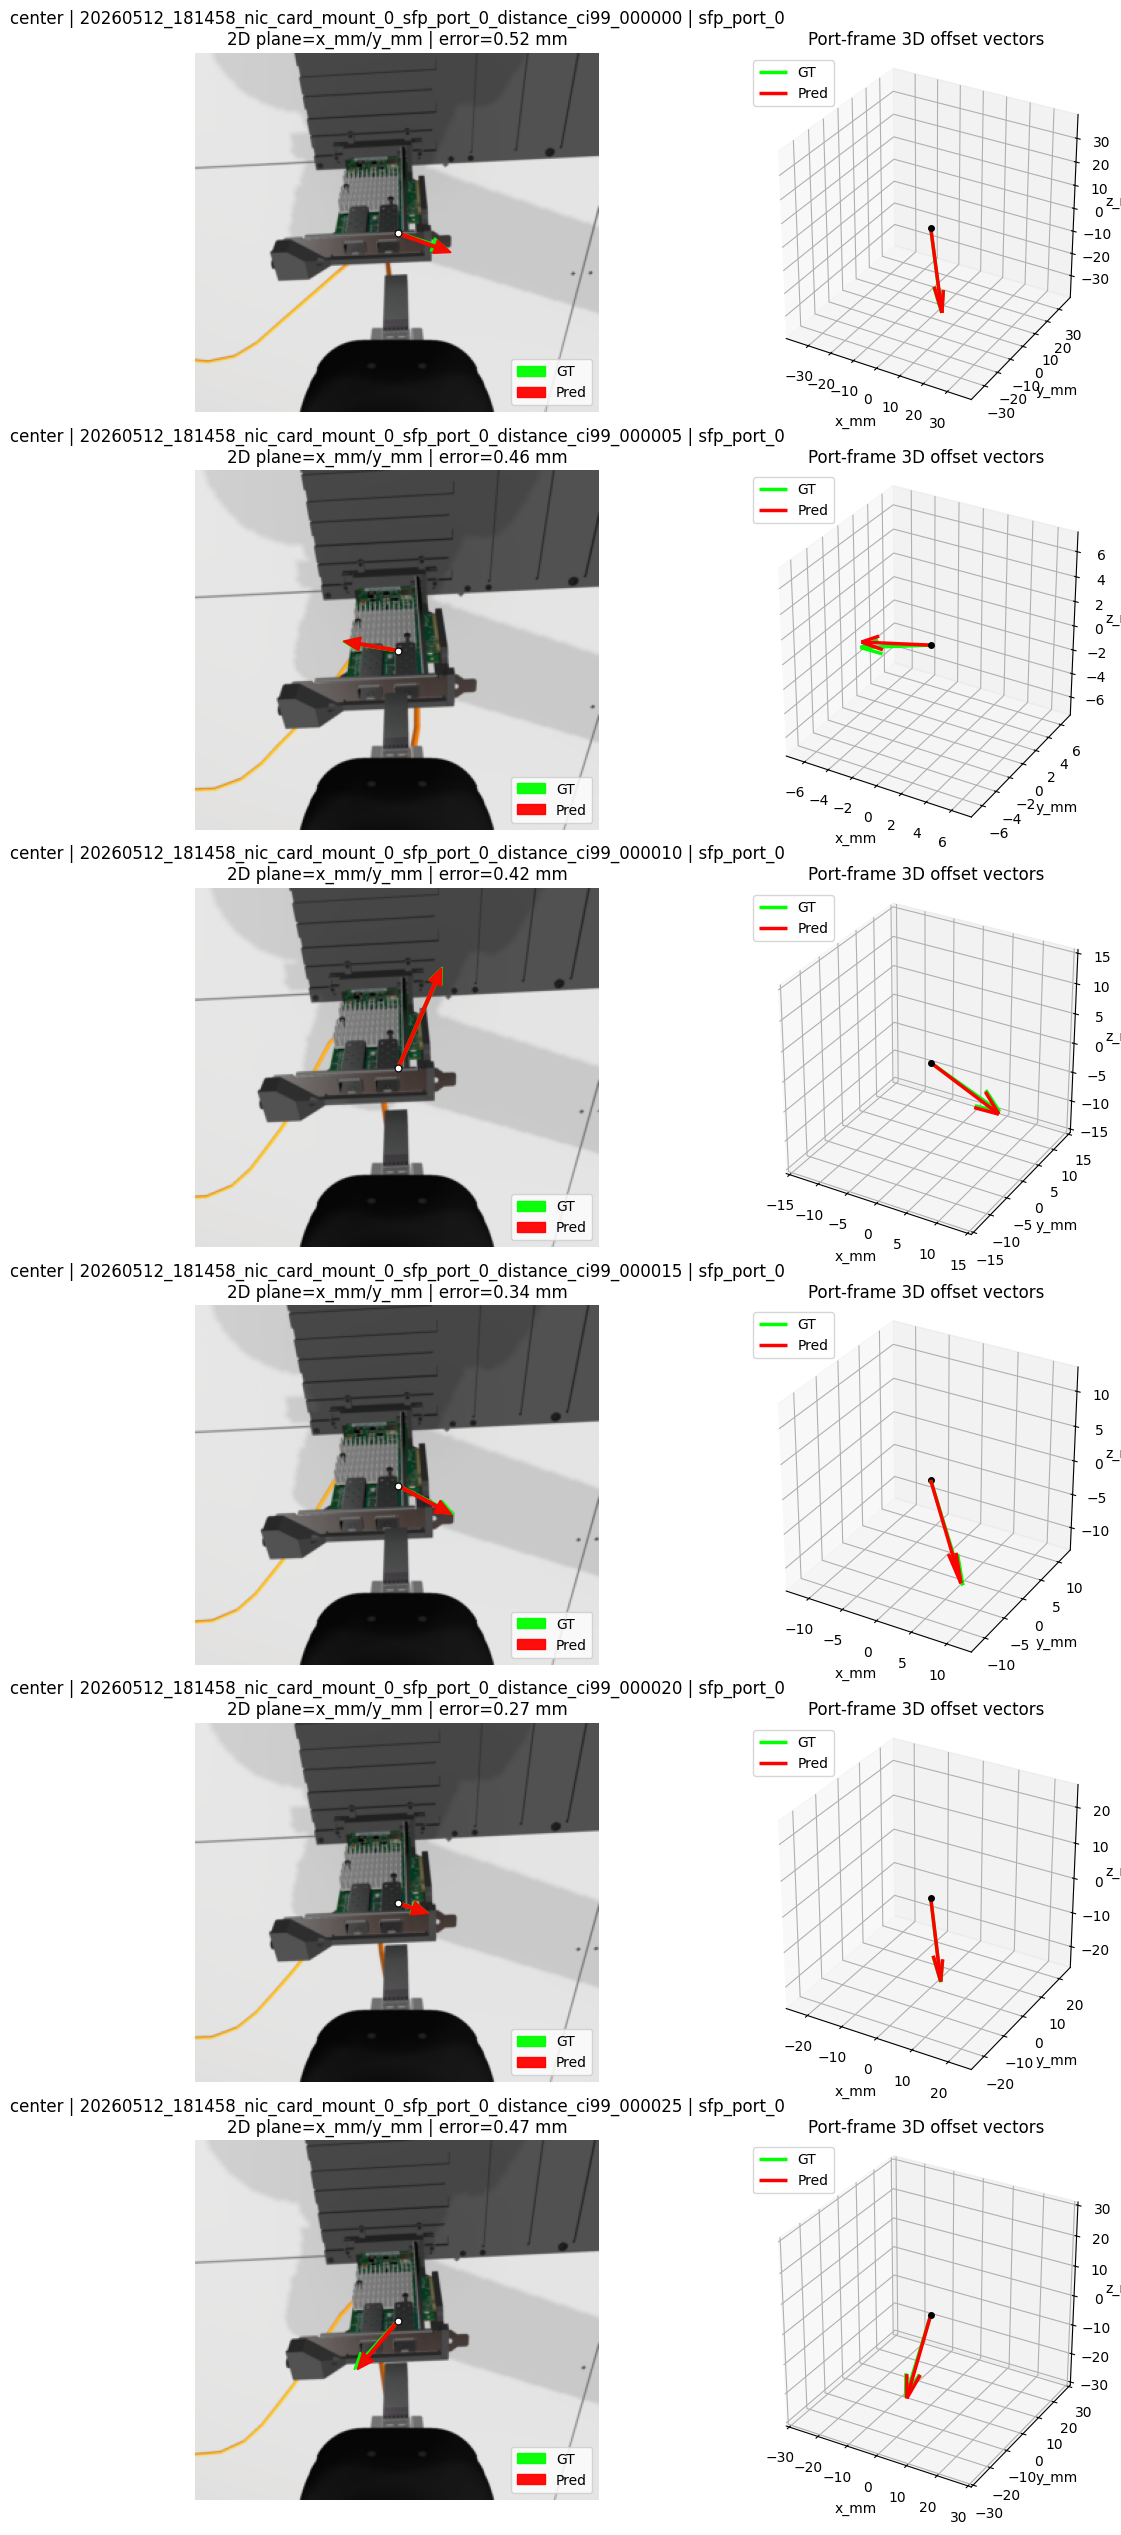

[{'sample_id': '20260512_181458_nic_card_mount_0_sfp_port_0_distance_ci99_000000',
  'port_name': 'sfp_port_0',
  'pred_xyz_mm': (6.287, -2.292, -34.471),
  'gt_xyz_mm': (5.978, -1.968, -34.73),
  'error_xyz_mm': (0.31, -0.324, 0.258),
  'euclidean_mm': 0.517},
 {'sample_id': '20260512_181458_nic_card_mount_0_sfp_port_0_distance_ci99_000005',
  'port_name': 'sfp_port_0',
  'pred_xyz_mm': (-6.508, 1.136, -2.188),
  'gt_xyz_mm': (-6.567, 1.09, -2.641),
  'error_xyz_mm': (0.059, 0.045, 0.453),
  'euclidean_mm': 0.459},
 {'sample_id': '20260512_181458_nic_card_mount_0_sfp_port_0_distance_ci99_000010',
  'port_name': 'sfp_port_0',
  'pred_xyz_mm': (5.181, 11.915, -13.572),
  'gt_xyz_mm': (5.244, 12.012, -13.164),
  'error_xyz_mm': (-0.063, -0.098, -0.408),
  'euclidean_mm': 0.424},
 {'sample_id': '20260512_181458_nic_card_mount_0_sfp_port_0_distance_ci99_000015',
  'port_name': 'sfp_port_0',
  'pred_xyz_mm': (6.37, -3.412, -11.434),
  'gt_xyz_mm': (6.625, -3.38, -11.663),
  'error_xyz_mm': 

In [26]:
# Visualize one validation batch: predicted vs GT offset direction.
# The vectors are in the SFP port label frame, in millimeters.
# Image arrows show the selected 2D plane only; the 3D plot shows the full vector.
import math
import numpy as np
import matplotlib.pyplot as plt

VIS_LOAD_BEST = True
VIS_NUM_EXAMPLES = 6
VIS_CAMERA = 'center'  # one of CAMERAS: 'left', 'center', 'right'
VIS_ARROW_PLANE = ('x_mm', 'y_mm')  # image overlay plane; try ('x_mm', 'z_mm') too
VIS_ARROW_SCALE_PX_PER_MM = 6.0
VIS_MAX_ARROW_PX = 90.0

_AXIS_INDEX = {'x_mm': 0, 'y_mm': 1, 'z_mm': 2}
_IMAGENET_MEAN = torch.tensor((0.485, 0.456, 0.406)).view(3, 1, 1)
_IMAGENET_STD = torch.tensor((0.229, 0.224, 0.225)).view(3, 1, 1)


def load_best_for_visualization():
    best_path = WEIGHT_ROOT / RUN_NAME / 'best.pt'
    if not VIS_LOAD_BEST:
        print('Using current in-memory model weights.')
        return
    if not best_path.is_file():
        print(f'best checkpoint not found, using current model: {best_path}')
        return
    checkpoint = torch.load(best_path, map_location=device)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model.load_state_dict(state_dict)
    print(f'loaded best checkpoint: {best_path}')
    if isinstance(checkpoint, dict) and 'metrics' in checkpoint:
        print('checkpoint metrics:', checkpoint['metrics'])


def predict_batch_mm(batch):
    images = batch['image'].to(device, non_blocking=True)
    port_ids = batch.get('port_id')
    if port_ids is not None:
        port_ids = port_ids.to(device, non_blocking=True)
    model.eval()
    with torch.inference_mode():
        pred_norm = model(images, port_ids).detach().cpu()
    return pred_norm * target_stats['std'] + target_stats['mean']


def batch_image_to_numpy(batch_images, sample_index, camera_name):
    image = batch_images[sample_index].detach().cpu()
    if image.ndim == 4:
        view_index = CAMERAS.index(camera_name)
        image = image[view_index]
    image = (image * _IMAGENET_STD + _IMAGENET_MEAN).clamp(0.0, 1.0)
    return image.permute(1, 2, 0).numpy()


def vector_to_image_delta(vector_mm, plane):
    x_axis, y_axis = plane
    delta = np.array(
        [
            float(vector_mm[_AXIS_INDEX[x_axis]]),
            -float(vector_mm[_AXIS_INDEX[y_axis]]),
        ],
        dtype=np.float64,
    )
    delta *= VIS_ARROW_SCALE_PX_PER_MM
    norm = np.linalg.norm(delta)
    if norm > VIS_MAX_ARROW_PX:
        delta *= VIS_MAX_ARROW_PX / norm
    return delta


def draw_image_arrow(ax, origin, delta, color, label):
    ax.arrow(
        origin[0],
        origin[1],
        delta[0],
        delta[1],
        color=color,
        width=2.0,
        head_width=10.0,
        head_length=12.0,
        length_includes_head=True,
        alpha=0.95,
        label=label,
    )


def set_equal_3d_limits(ax, vectors):
    values = np.asarray(vectors, dtype=np.float64)
    limit = max(5.0, float(np.abs(values).max()) * 1.15)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((1, 1, 1))


load_best_for_visualization()
viz_batch = next(iter(val_loader))
viz_pred_mm = predict_batch_mm(viz_batch)
viz_target_mm = viz_batch['raw_target'].detach().cpu()
viz_error_mm = viz_pred_mm - viz_target_mm
viz_num = min(VIS_NUM_EXAMPLES, viz_pred_mm.shape[0])

fig = plt.figure(figsize=(12, 4.2 * viz_num))
rows = []
for row in range(viz_num):
    pred_vec = viz_pred_mm[row].numpy()
    target_vec = viz_target_mm[row].numpy()
    error_vec = viz_error_mm[row].numpy()
    euclidean = float(np.linalg.norm(error_vec))

    image = batch_image_to_numpy(viz_batch['image'], row, VIS_CAMERA)
    image_ax = fig.add_subplot(viz_num, 2, row * 2 + 1)
    image_ax.imshow(image)
    height, width = image.shape[:2]
    origin = np.array([width * 0.5, height * 0.5], dtype=np.float64)
    draw_image_arrow(image_ax, origin, vector_to_image_delta(target_vec, VIS_ARROW_PLANE), 'lime', 'GT')
    draw_image_arrow(image_ax, origin, vector_to_image_delta(pred_vec, VIS_ARROW_PLANE), 'red', 'Pred')
    image_ax.scatter([origin[0]], [origin[1]], s=24, c='white', edgecolors='black', linewidths=0.8)
    image_ax.set_title(
        f"{VIS_CAMERA} | {viz_batch['sample_id'][row]} | {viz_batch['port_name'][row]}\n"
        f"2D plane={VIS_ARROW_PLANE[0]}/{VIS_ARROW_PLANE[1]} | error={euclidean:.2f} mm"
    )
    image_ax.axis('off')
    image_ax.legend(loc='lower right')

    vector_ax = fig.add_subplot(viz_num, 2, row * 2 + 2, projection='3d')
    vector_ax.quiver(0, 0, 0, target_vec[0], target_vec[1], target_vec[2], color='lime', linewidth=2.5, label='GT')
    vector_ax.quiver(0, 0, 0, pred_vec[0], pred_vec[1], pred_vec[2], color='red', linewidth=2.5, label='Pred')
    vector_ax.scatter([0], [0], [0], c='black', s=16)
    set_equal_3d_limits(vector_ax, [target_vec, pred_vec])
    vector_ax.set_xlabel('x_mm')
    vector_ax.set_ylabel('y_mm')
    vector_ax.set_zlabel('z_mm')
    vector_ax.set_title('Port-frame 3D offset vectors')
    vector_ax.legend(loc='upper left')

    rows.append({
        'sample_id': viz_batch['sample_id'][row],
        'port_name': viz_batch['port_name'][row],
        'pred_xyz_mm': tuple(round(float(v), 3) for v in pred_vec),
        'gt_xyz_mm': tuple(round(float(v), 3) for v in target_vec),
        'error_xyz_mm': tuple(round(float(v), 3) for v in error_vec),
        'euclidean_mm': round(euclidean, 3),
    })

plt.tight_layout()
plt.show()
rows
